# Data Science in Cybersecurity
## Data Cleaning and Preprocessing
### Task 1: Dataset Exploration
---

### Step 1.1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.max_rows', 20)        # limit row display
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the raw cybersecurity dataset
#Inspect Column Names and Data Types
df = pd.read_csv('cybersecurity_raw.csv')

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns\n')

# Preview the first 5 rows
df.head()

Dataset loaded successfully.
Shape: 520 rows × 17 columns



,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,Pkt Size Avg,Fwd IAT Mean,Bwd IAT Mean,Flow Bytes/s,Flow Pkts/s,Flag,Label
0,flow_0000,7.140.125.58,99999,171.84.26.102,22,Tcp,2024-01-03 10:47:07,NaN,212.00,140.00,527.75,2154.51,2757.13,819791.08,103.97,ACK,PortScan
1,flow_0001,27.44.216.9,51191,161.156.119.110,8080,Tcp,2024-01-19 14:55:33,NaN,-5.00,NaN,374.60,3870.88,1352.54,424592.44,708.53,SYN,benign
2,flow_0002,NaN,99999,168.46.48.1,443,HTTP,05/01/2024 04:20,NaN,-5.00,NaN,609.74,1044.10,178.00,71656.80,837.41,FIN,BENIGN
3,flow_0003,130.13.101.184,99999,55.244.39.34,22,HTTP,2024-01-20 00:36:58,-999.00,NaN,264.00,1463.45,374.99,3251.68,740429.12,518.97,FIN,ddos
4,flow_0004,140.214.112.115,51228,152.115.227.3,21,UDP,01-29-2024 22:31:54,9999999.00,NaN,452.00,1213.28,3138.95,1517.09,221694.04,382.59,FIN,benign


In [3]:
# Examine column names (look out for whitespace or inconsistent naming)
print('Column names:')
print(df.columns.tolist())

print('\nData types per column:')
print(df.dtypes)

Column names:
[' Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'Pkt Size Avg', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Flow Bytes/s', 'Flow Pkts/s', 'Flag', 'Label']

Data types per column:
 Flow ID             str
Src IP               str
Src Port           int64
Dst IP               str
Dst Port           int64
Protocol             str
Timestamp            str
Flow Duration    float64
Tot Fwd Pkts     float64
Tot Bwd Pkts     float64
Pkt Size Avg     float64
Fwd IAT Mean     float64
Bwd IAT Mean     float64
Flow Bytes/s     float64
Flow Pkts/s      float64
Flag                 str
Label                str
dtype: object


### Step 1.4 — Dataset Dimensions and Memory Usage

In [4]:
print(f'Total rows    : {df.shape[0]}')
print(f'Total columns : {df.shape[1]}')
print(f'\nMemory usage  :')
print(df.memory_usage(deep=True))
print(f'\nTotal memory  : {df.memory_usage(deep=True).sum() / 1024:.2f} KB')

Total rows    : 520
Total columns : 17

Memory usage  :
Index              132
 Flow ID         30160
Src IP           32091
Src Port          4160
Dst IP           32356
Dst Port          4160
Protocol         25918
Timestamp        34775
Flow Duration     4160
Tot Fwd Pkts      4160
Tot Bwd Pkts      4160
Pkt Size Avg      4160
Fwd IAT Mean      4160
Bwd IAT Mean      4160
Flow Bytes/s      4160
Flow Pkts/s       4160
Flag             25180
Label            27187
dtype: int64

Total memory  : 243.55 KB


In [5]:
# Statistical summary of numerical features
print('Statistical Summary (Numerical Columns):')
df.describe()

Statistical Summary (Numerical Columns):


/home/bash/Assignment2-Cyber-Visualization/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Src Port,Dst Port,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,Pkt Size Avg,Fwd IAT Mean,Bwd IAT Mean,Flow Bytes/s,Flow Pkts/s
count,520.00,520.00,397.00,351.00,272.00,510.00,507.00,498.00,518.00,502.00
mean,44812.05,4842.94,3593519.94,107.70,233.14,2879.05,2486.68,2479.43,NaN,498.75
std,43101.33,11851.71,4786830.93,157.65,144.21,14440.39,1477.20,1398.30,NaN,295.18
min,-1.00,21.00,-999.00,-5.00,0.00,-1.00,0.18,4.22,-inf,3.84
25%,-1.00,22.00,-999.00,-5.00,109.75,340.27,1317.16,1292.12,288660.07,226.73
50%,33113.50,80.00,60248.00,-5.00,209.50,749.26,2349.84,2560.16,527987.10,492.72
75%,99999.00,2013.25,9999999.00,228.00,357.00,1124.67,3772.58,3666.31,777859.73,759.77
max,99999.00,65246.00,9999999.00,500.00,500.00,99999.90,4979.57,4946.03,inf,999.14


In [6]:
# Summary of categorical/object columns
print('Categorical Column Summary:')
df.describe(include='object')

Categorical Column Summary:


/tmp/ipykernel_8682/1385593931.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Flow ID,Src IP,Dst IP,Protocol,Timestamp,Flag,Label
count,520,508,520,457,520,427,449
unique,500,489,500,7,499,5,6
top,flow_0031,205.55.127.50,103.42.78.72,ICMP,26/01/2024 20:41,SYN,DDoS
freq,2,2,2,78,2,99,85


### Step 1.6 — Missing Value Analysis

> **📸 SCREENSHOT HERE** — Capture both the missing value table and the bar chart.

In [7]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)'  : missing_pct
})

# Show only columns that have at least one missing value
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('Columns with missing values:')
print(missing_df)

Columns with missing values:
               Missing Count  Missing (%)
Tot Bwd Pkts             248        47.69
Tot Fwd Pkts             169        32.50
Flow Duration            123        23.65
Flag                      93        17.88
Label                     71        13.65
Protocol                  63        12.12
Bwd IAT Mean              22         4.23
Flow Pkts/s               18         3.46
Fwd IAT Mean              13         2.50
Src IP                    12         2.31
Pkt Size Avg              10         1.92
Flow Bytes/s               2         0.38


/tmp/ipykernel_8682/4251911151.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


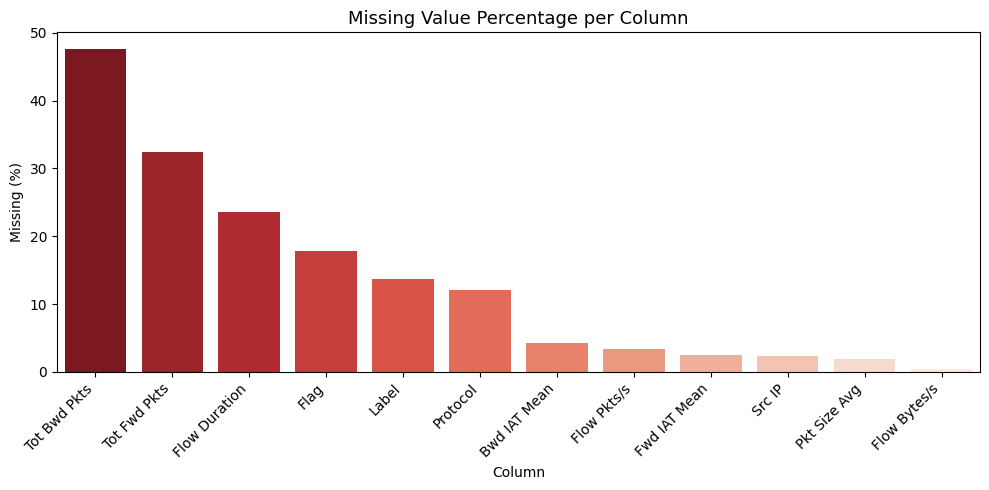

Chart saved as missing_values_chart.png


In [8]:
# Visualise missing values as a bar chart
plt.figure(figsize=(10, 5))
sns.barplot(
    x=missing_df.index,
    y='Missing (%)',
    data=missing_df,
    palette='Reds_r'
)
plt.title('Missing Value Percentage per Column', fontsize=13)
plt.xlabel('Column')
plt.ylabel('Missing (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values_chart.png', dpi=150)
plt.show()
print('Chart saved as missing_values_chart.png')

### Step 1.7 — Identify Obvious Quality Issues

> **📸 SCREENSHOT HERE** — Capture the printed list of quality issues found.

In [9]:
print('======= DATA QUALITY ISSUES IDENTIFIED =======')

# 1. Column name issues (leading/trailing whitespace)
bad_cols = [c for c in df.columns if c != c.strip()]
print(f'\n[1] Column names with whitespace: {bad_cols}')

# 2. Duplicate rows
dupes = df.duplicated().sum()
print(f'\n[2] Duplicate rows: {dupes}')

# 3. Mixed-case inconsistencies in categorical columns
for col in ['Protocol', 'Label', 'Flag']:
    if col in df.columns:
        unique_vals = df[col].dropna().unique()
        print(f'\n[3] Unique values in "{col}": {sorted(unique_vals)}')

# 4. Invalid port numbers (valid range: 0-65535)
invalid_src_ports = df[df['Src Port'].notna() & (~df['Src Port'].between(0, 65535))]
print(f'\n[4] Invalid Src Port values: {invalid_src_ports["Src Port"].unique()}')

# 5. Negative flow durations
neg_duration = df[df['Flow Duration'] < 0]
print(f'\n[5] Negative Flow Duration entries: {len(neg_duration)}')

# 6. Infinite values
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f'\n[6] Total infinite values (inf/-inf): {inf_count}')

# 7. Inconsistent timestamp formats
print(f'\n[7] Sample Timestamp values (first 10):')
print(df['Timestamp'].head(10).tolist())

print('\n======= END OF QUALITY SUMMARY =======')

======= DATA QUALITY ISSUES IDENTIFIED =======

[1] Column names with whitespace: [' Flow ID']

[2] Duplicate rows: 20

[3] Unique values in "Protocol": ['HTTP', 'ICMP', 'TCP', 'Tcp', 'UDP', 'tcp', 'udp']

[3] Unique values in "Label": ['BENIGN', 'Brute Force', 'DDoS', 'PortScan', 'benign', 'ddos']

[3] Unique values in "Flag": ['ACK', 'FIN', 'PSH', 'RST', 'SYN']

[4] Invalid Src Port values: [99999    -1]

[5] Negative Flow Duration entries: 124

[6] Total infinite values (inf/-inf): 24

[7] Sample Timestamp values (first 10):
['2024-01-03 10:47:07', '2024-01-19 14:55:33', '05/01/2024 04:20', '2024-01-20 00:36:58', '01-29-2024 22:31:54', '01-22-2024 15:26:12', '18/01/2024 06:19', '2024-01-17 03:11:41', '2024-01-26 21:33:17', '01-23-2024 14:34:27']

======= END OF QUALITY SUMMARY =======


### Step 1.8 — Label Distribution

> **📸 SCREENSHOT HERE** — Capture the label distribution chart.

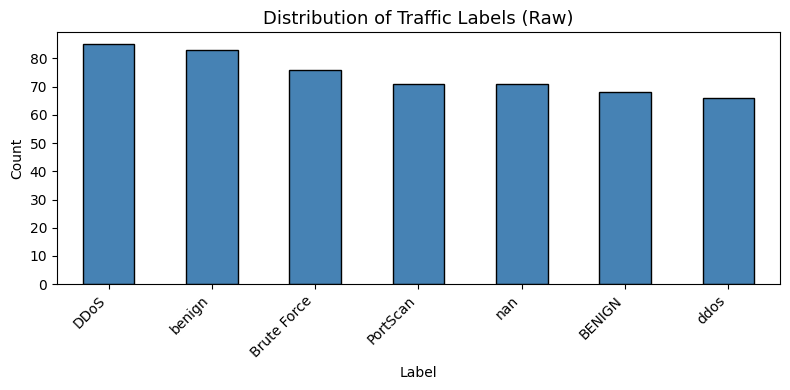

Chart saved as label_distribution.png


In [10]:
# Plot the distribution of traffic labels
label_counts = df['Label'].value_counts(dropna=False)

plt.figure(figsize=(8, 4))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Traffic Labels (Raw)', fontsize=13)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print('Chart saved as label_distribution.png')

---
## Task 1 Summary

| Issue | Details |
|---|---|
| Rows × Columns | 520 × 17 |
| Duplicate Rows | 20 |
| Columns with Missing Values | 12 |
| Invalid Port Numbers | Present (negative and >65535) |
| Negative Flow Durations | Present |
| Infinite Values | Present in Flow Bytes/s |
| Inconsistent Casing | Protocol, Label columns |
| Mixed Timestamp Formats | 3 different formats detected |
| Column Name Issues | Leading whitespace in ' Flow ID' |

> **Next Step:** Task 2 — Structural Error Correction